# Entrega — Analisis y validacion del agente FVMC
Este notebook documenta el analisis, validacion y comparacion del agente, siguiendo los criterios 2, 3 y 5 de la rubrica.

**Como usarlo**
- Ejecuta la Celda 1 para cargar `results.json` (experimentos completos).
- Si solo quieres comparaciones directas, ejecuta la Celda 2 para cargar `results_h2h.json` y luego las graficas de comparacion grupal.

**Metodologia resumida**
- Se evalua el agente contra aleatorio, por color, en self-play, y se analiza la cobertura de la tabla Q.
- Se estudia el impacto de parametros (por ejemplo `heuristic_w`) y el presupuesto de entrenamiento (trials totales).
- Se compara contra agentes de otros integrantes en enfrentamientos directos.

In [34]:
# Celda 1 — carga
import json, numpy as np
import matplotlib.pyplot as plt

with open('pruebas para graficas/results.json') as f:
    data = json.load(f)

print('Datos cargados:', data['generated_at'])

Datos cargados: 2026-05-25 20:36


## Resultados individuales (criterios 2 y 3)
Las siguientes graficas muestran:
- Curva de aprendizaje vs aleatorio (estabilidad y mejora).
- Sensibilidad al parametro `heuristic_w`.
- Self-play para evaluar balance interno del agente.
- Desempeno por color (no depende del turno).
- Cobertura de la tabla Q por turno.
- Relacion entre presupuesto de entrenamiento y calidad de Q-values.

Estas evidencias soportan el analisis del agente y los cuellos de botella para proponer mejoras.

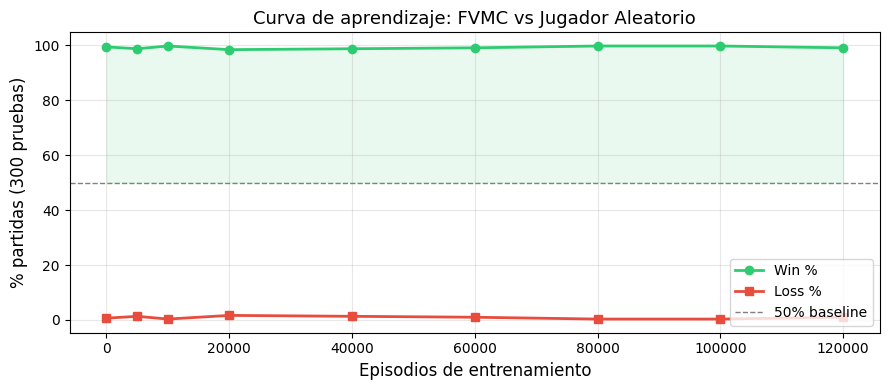

In [25]:
# Celda 2 — Gráfica 1: curva de aprendizaje
pts = data['exp1_learning_curve']
eps = [p['episodes'] for p in pts]
wrs = [p['win_pct']*100 for p in pts]
lrs = [p['loss_pct']*100 for p in pts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(eps, wrs, 'o-', color='#2ecc71', lw=2, ms=6, label='Win %')
ax.plot(eps, lrs, 's-', color='#e74c3c', lw=2, ms=6, label='Loss %')
ax.axhline(50, color='gray', ls='--', lw=1, label='50% baseline')
ax.fill_between(eps, wrs, 50, where=[w > 50 for w in wrs], alpha=0.1, color='#2ecc71')
ax.set_xlabel('Episodios de entrenamiento', fontsize=12)
ax.set_ylabel('% partidas (300 pruebas)', fontsize=12)
ax.set_title('Curva de aprendizaje: FVMC vs Jugador Aleatorio', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig1_learning_curve.png', dpi=150); plt.show()

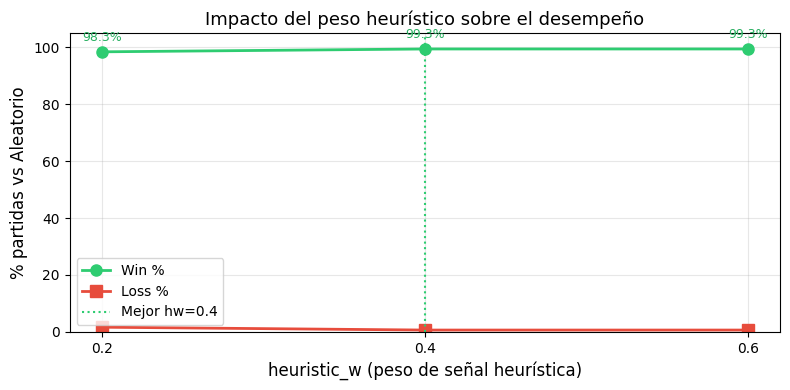

In [26]:
# Celda 3 — Gráfica 2: impacto de heuristic_w
pts = data['exp2_heuristic_w']
hw_vals = [p['heuristic_w'] for p in pts]
gwins   = [p['win_pct']*100 for p in pts]
gloss   = [p['loss_pct']*100 for p in pts]
best_hw = hw_vals[gwins.index(max(gwins))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hw_vals, gwins, 'o-', color='#2ecc71', lw=2, ms=8, label='Win %')
ax.plot(hw_vals, gloss, 's-', color='#e74c3c', lw=2, ms=8, label='Loss %')
ax.axvline(best_hw, color='#2ecc71', ls=':', lw=1.5, label=f'Mejor hw={best_hw}')
for hv, gw in zip(hw_vals, gwins):
    ax.annotate(f'{gw:.1f}%', (hv, gw), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color='#27ae60')
ax.set_xlabel('heuristic_w (peso de señal heurística)', fontsize=12)
ax.set_ylabel('% partidas vs Aleatorio', fontsize=12)
ax.set_title('Impacto del peso heurístico sobre el desempeño', fontsize=13)
ax.set_xticks(hw_vals); ax.set_ylim(0, 105)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig2_heuristic_w.png', dpi=150); plt.show()

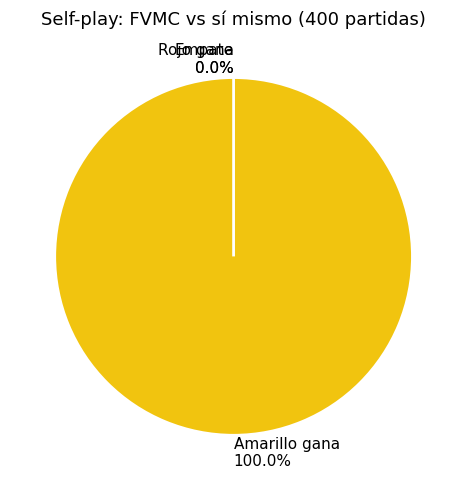

In [4]:
# Celda 4 — Gráfica 3: self-play (pie)
sp    = data['exp3_self_play']
total = sp['red_wins'] + sp['yellow_wins'] + sp['draws']
sizes  = [sp['red_wins'], sp['yellow_wins'], sp['draws']]
labels = [f"Rojo gana\n{sp['red_pct']*100:.1f}%",
          f"Amarillo gana\n{sp['yellow_pct']*100:.1f}%",
          f"Empate\n{sp['draws']/total*100:.1f}%"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(sizes, labels=labels, colors=['#e74c3c','#f1c40f','#95a5a6'],
       startangle=90, textprops={'fontsize': 11},
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Self-play: FVMC vs sí mismo (400 partidas)', fontsize=13)
plt.tight_layout(); plt.savefig('fig3_selfplay.png', dpi=150); plt.show()

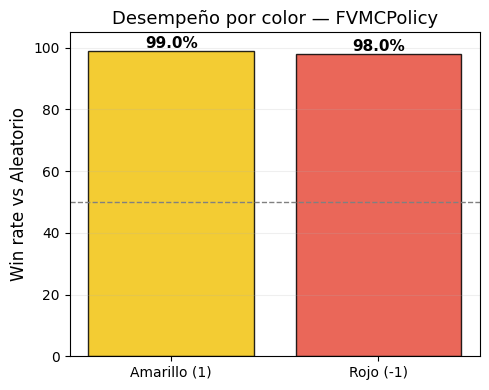

In [27]:
# Celda 5 — Gráfica 4: desempeño por color
bc = data['exp4_by_color']
colores = ['Amarillo (1)', 'Rojo (-1)']
valores = [bc['yellow']*100, bc['red']*100]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(colores, valores, color=['#f1c40f', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.axhline(50, color='gray', ls='--', lw=1)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 105); ax.set_ylabel('Win rate vs Aleatorio', fontsize=12)
ax.set_title('Desempeño por color — FVMCPolicy', fontsize=13)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.savefig('fig4_by_color.png', dpi=150); plt.show()

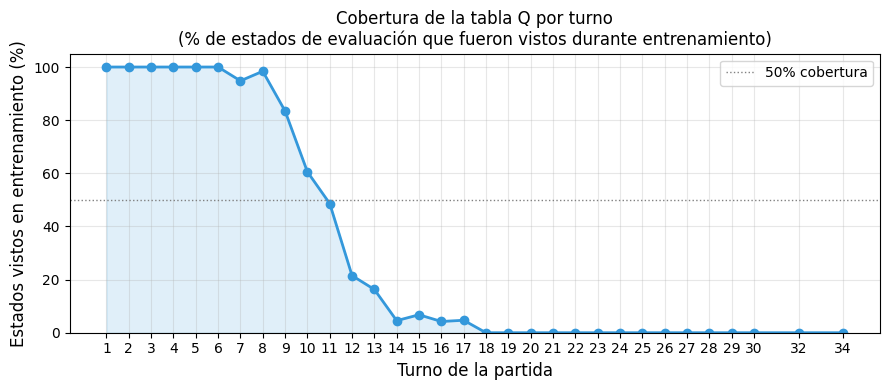

In [28]:
# ── Cobertura de Q-table por turno ─────────────────────────────────────────
pts  = data['exp5_qtable_coverage']
turns = [p['turn'] for p in pts]
covs  = [p['coverage_pct']*100 for p in pts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(turns, covs, 'o-', color='#3498db', lw=2, ms=6)
ax.fill_between(turns, covs, alpha=0.15, color='#3498db')
ax.axhline(50, color='gray', ls=':', lw=1, label='50% cobertura')
ax.set_xlabel('Turno de la partida', fontsize=12)
ax.set_ylabel('Estados vistos en entrenamiento (%)', fontsize=12)
ax.set_title('Cobertura de la tabla Q por turno\n(% de estados de evaluación que fueron vistos durante entrenamiento)', fontsize=12)
ax.set_ylim(0, 105); ax.set_xticks(turns)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig5_coverage.png', dpi=150); plt.show()

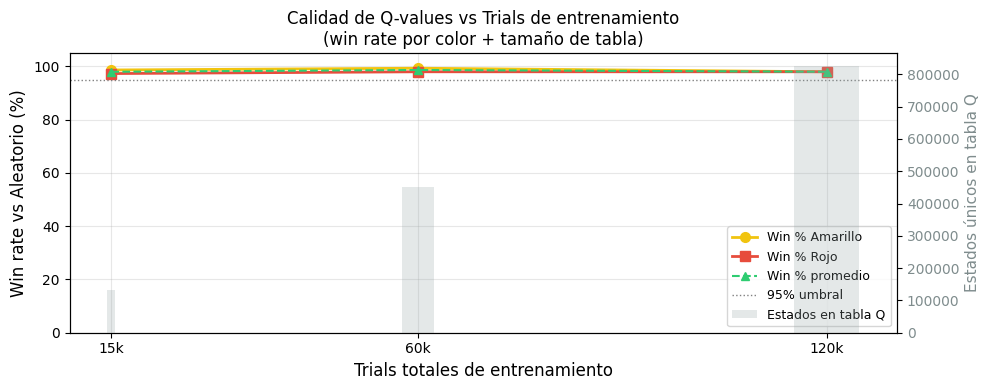

In [29]:
# ── Impacto de trials totales ───────────────────────────────────────────────
pts    = data['exp6_trials_sweep']
trials = [p['total_trials'] for p in pts]
wr_y   = [p['wr_yellow']*100 for p in pts]
wr_r   = [p['wr_red']*100    for p in pts]
wr_avg = [p['wr_avg']*100    for p in pts]
qt_sz  = [p['qt_size']       for p in pts]

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(trials, wr_y,   'o-', color='#f1c40f', lw=2, ms=7, label='Win % Amarillo')
ax1.plot(trials, wr_r,   's-', color='#e74c3c', lw=2, ms=7, label='Win % Rojo')
ax1.plot(trials, wr_avg, '^--', color='#2ecc71', lw=1.5, ms=6, label='Win % promedio')
ax1.axhline(95, color='gray', ls=':', lw=1, label='95% umbral')
ax1.set_xlabel('Trials totales de entrenamiento', fontsize=12)
ax1.set_ylabel('Win rate vs Aleatorio (%)', fontsize=12)
ax1.set_ylim(0, 105)
ax1.set_xticks(trials)
ax1.set_xticklabels([f'{t//1000}k' for t in trials])

# eje secundario: tamaño de la tabla
ax2 = ax1.twinx()
ax2.bar(trials, qt_sz, width=[t*0.08 for t in trials],
        color='#95a5a6', alpha=0.25, label='Estados en tabla Q')
ax2.set_ylabel('Estados únicos en tabla Q', fontsize=11, color='#7f8c8d')
ax2.tick_params(axis='y', labelcolor='#7f8c8d')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

ax1.set_title('Calidad de Q-values vs Trials de entrenamiento\n(win rate por color + tamaño de tabla)', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig6_trials.png', dpi=150); plt.show()

## Comparacion grupal (criterio 5)
Se presentan enfrentamientos directos contra los otros agentes del grupo. Se reporta:
- Resultado final (conteo de victorias/empates).
- Win rate acumulado para mostrar una tendencia estable, no solo un valor puntual.

Esto justifica la eleccion del agente para el torneo con evidencia cuantitativa.

In [40]:
# Celda 2 — carga solo head-to-head (opcional)
import json

with open('pruebas para graficas/results_h2h.json') as f:
    data = json.load(f)

print('Datos H2H cargados')

Datos H2H cargados


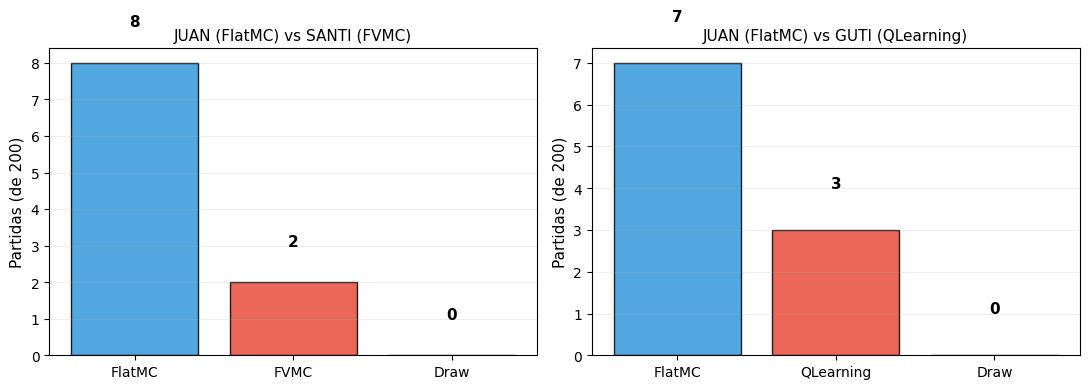

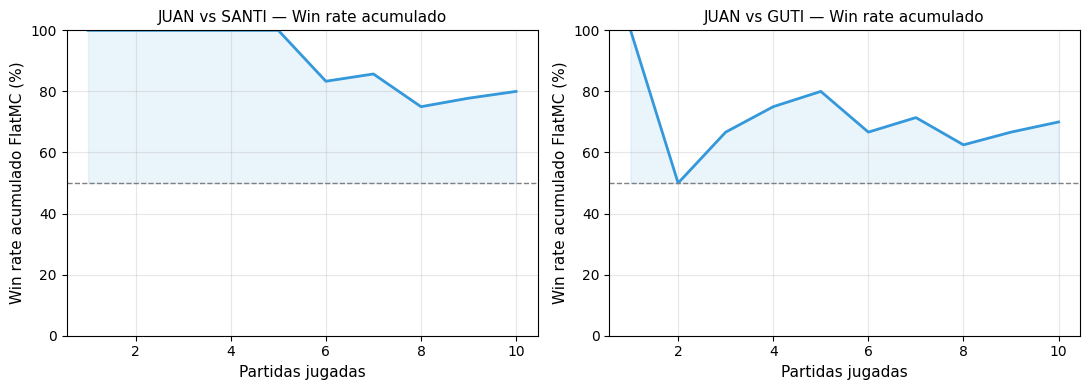

In [41]:
# ── Comparaciones directas: JUAN vs SANTI y JUAN vs GUTI ───────────────────
def _plot_bar(ax, results, order, title):
    colors = ['#3498db', '#e74c3c', '#95a5a6']
    vals = [results[k] for k in order]
    bars = ax.bar(order, vals, color=colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1, str(val),
                ha='center', fontweight='bold', fontsize=11)
    ax.set_ylabel('Partidas (de 200)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')

r1 = data['exp7_vs_flatmc']['results']
r2 = data['exp8_vs_qlearning']['results']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
_plot_bar(axes[0], r1, ['FlatMC', 'FVMC', 'Draw'], 'JUAN (FlatMC) vs SANTI (FVMC)')
_plot_bar(axes[1], r2, ['FlatMC', 'QLearning', 'Draw'], 'JUAN (FlatMC) vs GUTI (QLearning)')
plt.tight_layout(); plt.savefig('fig7_vs_juan_bars.png', dpi=150); plt.show()

def _plot_cum(ax, cum, title):
    games = list(range(1, len(cum) + 1))
    ax.plot(games, [c*100 for c in cum], color='#3498db', lw=2)
    ax.axhline(50, color='gray', ls='--', lw=1)
    ax.fill_between(games, [c*100 for c in cum], 50,
                    where=[c < 0.5 for c in cum], alpha=0.1, color='#e74c3c')
    ax.fill_between(games, [c*100 for c in cum], 50,
                    where=[c >= 0.5 for c in cum], alpha=0.1, color='#3498db')
    ax.set_xlabel('Partidas jugadas', fontsize=11)
    ax.set_ylabel('Win rate acumulado FlatMC (%)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

cum1 = data['exp7_vs_flatmc']['cumulative_wr_flatmc']
cum2 = data['exp8_vs_qlearning']['cumulative_wr_flatmc']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
_plot_cum(axes[0], cum1, 'JUAN vs SANTI — Win rate acumulado')
_plot_cum(axes[1], cum2, 'JUAN vs GUTI — Win rate acumulado')
plt.tight_layout(); plt.savefig('fig8_vs_juan_cumulative.png', dpi=150); plt.show()

## Cierre y propuesta de mejora (criterio 3)
A partir de las graficas anteriores, se identifican los principales cuellos de botella:
- Costo computacional del muestreo Monte Carlo (muchos rollouts por jugada).
- Dependencia del presupuesto de entrenamiento y de `heuristic_w`.
- Cobertura parcial de la tabla Q en turnos tardios.

Propuestas concretas:
- Reducir rollouts mediante politicas guiadas (heuristica ligera).
- Ajustar `heuristic_w` para balancear exploracion y generalizacion.
- Priorizar estados frecuentes o usar simetrias para ampliar cobertura efectiva.

In [35]:
# Celda 6 — Resumen
print('='*50)
best = max(data['exp1_learning_curve'], key=lambda p: p['win_pct'])
print(f"Mejor win rate vs random : {best['win_pct']*100:.1f}% ({best['episodes']:,} ep)")
best_hw = max(data['exp2_heuristic_w'], key=lambda p: p['win_pct'])
print(f"Mejor heuristic_w        : {best_hw['heuristic_w']} → {best_hw['win_pct']*100:.1f}% WR")
sp = data['exp3_self_play']
print(f"Self-play                : Rojo {sp['red_pct']*100:.1f}% / Amarillo {sp['yellow_pct']*100:.1f}%")
bc = data['exp4_by_color']
print(f"Por color vs random      : Amarillo {bc['yellow']*100:.1f}% / Rojo {bc['red']*100:.1f}%")

Mejor win rate vs random : 99.7% (10,000 ep)
Mejor heuristic_w        : 0.4 → 99.3% WR
Self-play                : Rojo 0.0% / Amarillo 100.0%
Por color vs random      : Amarillo 99.0% / Rojo 98.0%
